# Predicting F1 Pit Stops

## Loading and Importing the data

In [20]:
import pandas as pd
import numpy as np

In [21]:
data = pd.read_csv("Predicting F1 Pit Stops/playground-series-s6e5/train.csv")

In [22]:
target_col = 'PitNextLap'
y = data[target_col]
X = data.drop(columns=[target_col])

Since there is a separate test set provided by Kaggle, a separate held out set is not necessary here. It is better to use all the available data in the train set to make modelling assumptions

### Basic Information about Data

In [23]:
print(y.value_counts())

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64


In [24]:
print(X.dtypes)

id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object


In [25]:
print(X.nunique())

id                        439140
Driver                       887
Compound                       5
Race                          26
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
dtype: int64


### Description of Dataset

This ia large dataset with over 300000 rows. 

The problem involves classification of a minority class.

#### Descriptions of the Columns

The ID is not useful for predictive purposes (checked through correlation with y)

Driver, Compound, Race with are not numeric so they need to be encoded 

Year, PitStop, Lap number, Stint, tyre life, position and position change are discrete variables

Finally, lap time, lap time delta and cumulative and race progress (technically fraction based) are continuous, 

## Data PreProcessing

In [26]:
X = X.drop(columns='id')

In [27]:
numeric_columns = X.select_dtypes(include='number').columns
print(numeric_columns)

Index(['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change'],
      dtype='object')


In [28]:
numeric_X = X[numeric_columns]
numeric_X.corrwith(y).sort_values(ascending=False)

TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
dtype: float64

### Assigning Numerical vs Categorical for Discrete Data

For the discrete variables, it makes sense to check whether the variables should be assigned as numerical or categorical.

In particular, we need to check if the numeric ordering actually reflects the relationship with the target variable.

This is done by plotting a graph treating the values as numeric and checking if they follow any sort of observable trend.

In [29]:
unique_numeric_counts = numeric_X.nunique()
discrete_columns = unique_numeric_counts[unique_numeric_counts<100].index
print(discrete_columns)

Index(['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'Position_Change'],
      dtype='object')


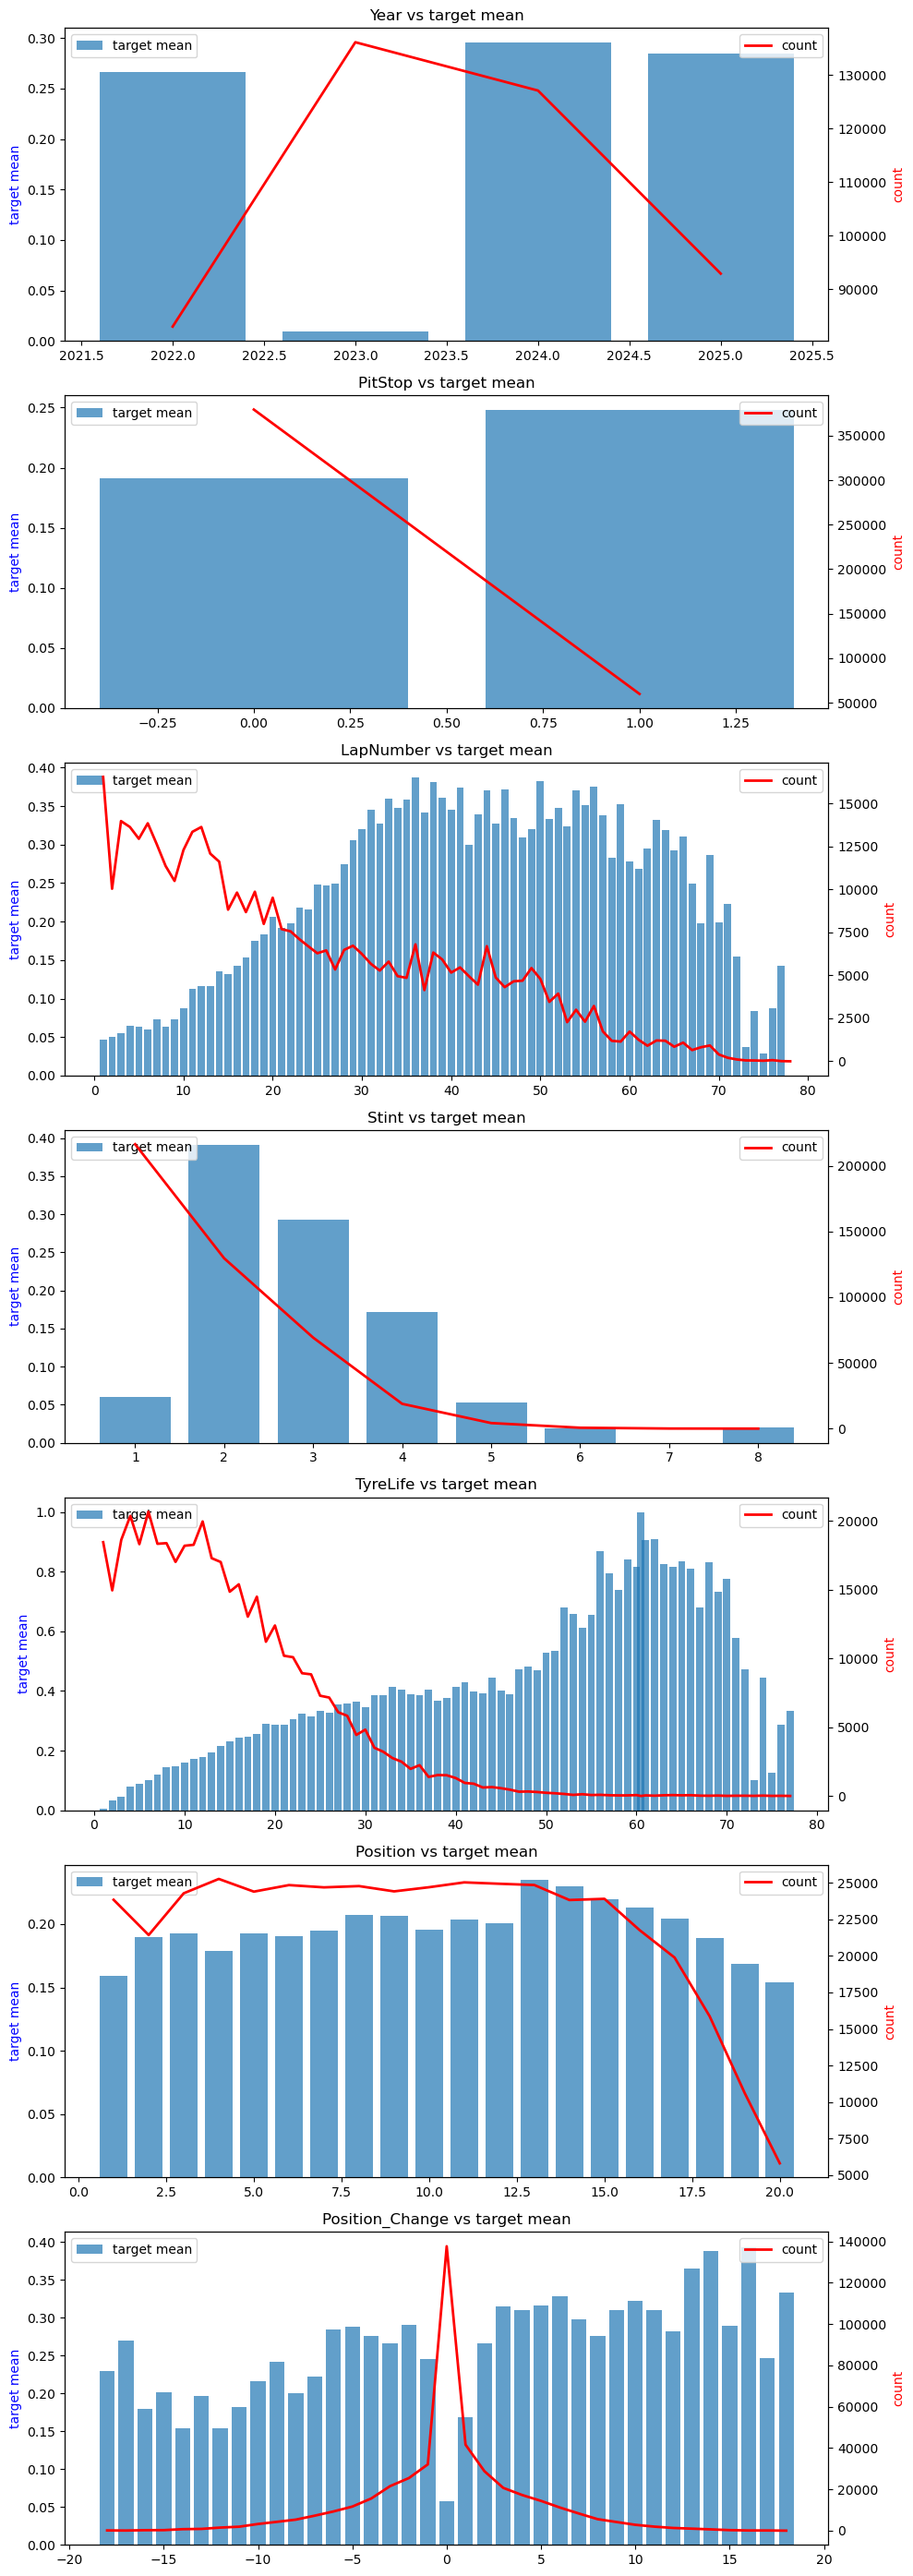

In [30]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(len(discrete_columns), 1, figsize=(10, 4*len(discrete_columns)))

for ax, col in zip(axes, discrete_columns):
    result = y.groupby(X[col]).agg(['mean', 'count'])
    
    # mean on left axis
    ax.bar(result.index, result['mean'], alpha=0.7, label='target mean')
    ax.set_ylabel('target mean', color='blue')
    ax.set_title(f'{col} vs target mean')
    
    # count on right axis
    ax2 = ax.twinx()
    ax2.plot(result.index, result['count'], color='red', linewidth=2, label='count')
    ax2.set_ylabel('count', color='red')
    
    # legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

From the graphs above, it seems clear that Year, PitStop, Stint should be treated as categorical. Position, TyreLife and LapNumber seem to exhibit more of a pattern between similar values so are labelled as numeric. Position seems ambiguous and is treated as categorical (in either case it is unlikely to be a very predictive feature given the similarity between the values)

### Sorting out Text Columns

The text columns are Driver, Compound, Race with 887, 5, 26 values respectively. These can all be treated as categorical types

In [31]:
text_columns = X.select_dtypes(include='object').columns
print(text_columns)

Index(['Driver', 'Compound', 'Race'], dtype='object')


In [32]:
result = y.groupby(X['Driver']).agg(['mean', 'count'])
result = result[result['count']>100]
print(result.sort_values('mean', ascending=False))

            mean  count
Driver                 
VET     0.565460    359
MSC     0.473239    355
HAD     0.462069    435
STR     0.427451   1275
ANT     0.410072    417
...          ...    ...
D347    0.053097    113
D340    0.049587    121
D348    0.048544    103
D349    0.046729    107
DEV     0.014184    282

[484 rows x 2 columns]


### Applying LGB

Here the LGB model will be tested

The two types of columns that need to be transformed in some way are the numerical categorical columns and the text columns.

In general these are dealt with using OneHotEncoding or CatEncoding or labelling columns as categorical 

One Hot encoding is generally reserved for columns with fewer distinct values while CatEncoding can handle more distinct values



In [33]:
import xgboost as xgb 
import lightgbm as lgb
from category_encoders import CatBoostEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report


In [37]:
numerical_categorical_columns = ['Year', 'PitStop', 'Stint', 'Position']
all_categorical = list(numerical_categorical_columns) + list(text_columns)
print(X[all_categorical].nunique())

Year          4
PitStop       2
Stint         8
Position     20
Driver      887
Compound      5
Race         26
dtype: int64


In [38]:
model_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
for col in all_categorical:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
model_lgb.fit(X_train, y_train)
y_probs = model_lgb.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.10f}')

Test AUC: 0.9399961513


In [39]:
cat_columns = all_categorical
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(handle_unknown='ignore'), cat_columns)],
    remainder='passthrough').set_output(transform = 'pandas')
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_lgb)])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
print(X_train.dtypes)
y_probs = pipeline.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.10f}')

Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object
Test AUC: 0.9423915231


It seems that CAT encoding gives better results than setting things as categorical.
Now, to check the effects of one hot encoding. 

In [40]:
one_hot_columns = ['Race', 'Compound']
cat_columns = [col for col in all_categorical if col not in one_hot_columns]
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(handle_unknown='ignore'), cat_columns),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_columns)],
    remainder='passthrough').set_output(transform = 'pandas')
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_lgb)])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
print(X_train.dtypes)
y_probs = pipeline.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.10f}')

Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object
Test AUC: 0.9440481519


In [41]:
one_hot_columns = ['Race', 'Compound', 'Year', 'PitStop','Stint']
cat_columns = ['Driver', 'Position']
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(handle_unknown='ignore'), cat_columns),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_columns)],
    remainder='passthrough').set_output(transform = 'pandas')
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_lgb)])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


pipeline.fit(X_train, y_train)
print(X_train.dtypes)
y_probs = pipeline.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.10f}')

Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object
Test AUC: 0.9442697991


The sparsity issue doesn't seem to be significant for these smaller column values. Next, it is best to further tune the parameters.

In [42]:
one_hot_columns = ['Race', 'Compound', 'Year', 'PitStop','Stint']
cat_columns = ['Driver', 'Position']
param_grid = {'model__n_estimators':[100, 500,1000], 'model__num_leaves':[15, 31, 63]}
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(), cat_columns),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_columns)],
    remainder='passthrough'
).set_output(transform='pandas')
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))])
grid_search = GridSearchCV(
    pipeline, 
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
grid_search.fit(X_train, y_train)
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.3f}')
y_probs = grid_search.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.3f}')

Best params: {'model__n_estimators': 1000, 'model__num_leaves': 31}
Best CV AUC: 0.947
Test AUC: 0.950


In [43]:
one_hot_columns = ['Race', 'Compound', 'Year', 'PitStop','Stint']
cat_columns = ['Driver', 'Position']
param_grid = {'model__n_estimators':[1000, 2000, 5000]}
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(), cat_columns),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_columns)],
    remainder='passthrough'
).set_output(transform='pandas')
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))])
grid_search = GridSearchCV(
    pipeline, 
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
grid_search.fit(X_train, y_train)
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.3f}')
y_probs = grid_search.predict_proba(X_test)[:, 1]
print(f'Test AUC: {roc_auc_score(y_test, y_probs):.3f}')

Best params: {'model__n_estimators': 1000}
Best CV AUC: 0.947
Test AUC: 0.950


Therefore the final parameters are set for the model

## Final Prediction Section

In [44]:
final_test_data = pd.read_csv("Predicting F1 Pit Stops/playground-series-s6e5/test.csv")

In [45]:
print(final_test_data.columns)

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change'],
      dtype='object')


In [46]:
one_hot_columns = ['Race', 'Compound', 'Year', 'PitStop','Stint']
cat_columns = ['Driver', 'Position']
preprocessor = ColumnTransformer(transformers=[
    ('cat_enc', CatBoostEncoder(), cat_columns),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_columns)],
    remainder='passthrough'
).set_output(transform='pandas')

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42, n_estimators=1000, num_leaves = 31, verbose=-1, n_jobs=-1))])

pipeline.fit(X, y)

final_predictions = pipeline.predict_proba(final_test_data.drop(columns=['id']))[:, 1]

In [47]:
submission = pd.DataFrame({
    'id': final_test_data['id'],         
    'target': final_predictions       
})
submission.to_csv('submission.csv', index=False)

In [ ]:
print(len(final_test_data))     
print(len(final_predictions))    

188165
188165
